# A/B-тестирование: анализ агрегированных данных

**Контекст**: Мы хотим понять, увеличивает ли новая версия страницы (test) кликабельность (CTR)
по сравнению с текущей (control).  
    
**Данные**: агрегированные по пользователям (views, clicks) за период эксперимента.  
    
**Целевая метрика**: общий CTR = общие клики / общие показы.  
    
**Гипотезы**:
- H₀: CTR(test) = CTR(control)
- H₁: CTR(test) ≠ CTR(control)
- Уровень значимости α = 0.05

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

plt.style.use('ggplot')

In [2]:
df = pd.read_csv('ab_test_results_aggregated_views_clicks_2.csv')

## 1. Обзор данных

Распределение по группам: control – 60 000, test – 60 000

In [3]:
df.head()

,user_id,group,views,clicks
0,1,control,10.0,0.0
1,2,control,1.0,0.0
2,3,control,1.0,0.0
3,4,control,2.0,0.0
4,5,control,3.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   user_id  120000 non-null  int64  
 1   group    120000 non-null  object 
 2   views    120000 non-null  float64
 3   clicks   120000 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.7+ MB


In [5]:
df.dtypes

user_id      int64
group       object
views      float64
clicks     float64
dtype: object

## 2. Анализ распределений

#### Распределенние по просмотрам и кликам

array([[<Axes: title={'center': 'views'}>,
        <Axes: title={'center': 'clicks'}>]], dtype=object)

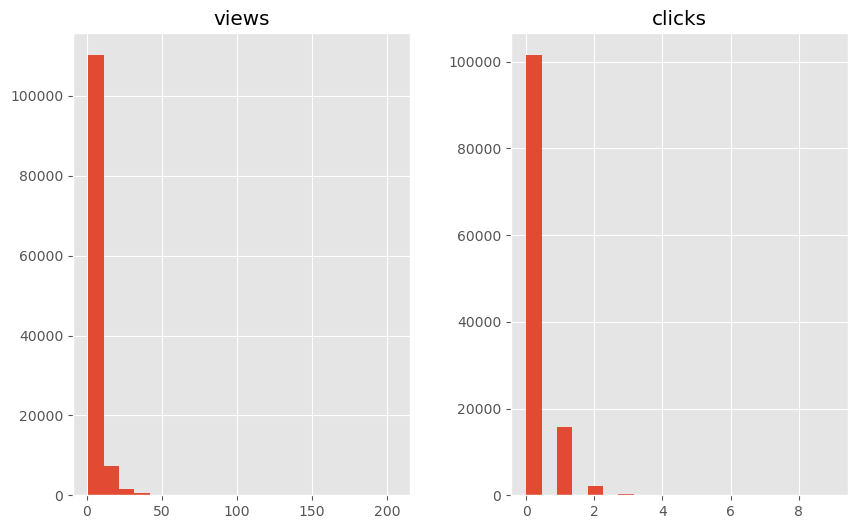

In [6]:
df[['views', 'clicks']].hist(bins=20, figsize=(10, 6))

In [7]:
df['group'].unique()

array(['control', 'test'], dtype=object)

In [8]:
df['ctr'] = df['clicks'] / df['views']

In [9]:
df.describe()

,user_id,views,clicks,ctr
count,120000.000000,120000.000000,120000.000000,120000.000000
mean,60000.500000,4.991075,0.182692,0.036651
std,34641.160489,5.915200,0.472547,0.117812
min,1.000000,1.000000,0.000000,0.000000
25%,30000.750000,2.000000,0.000000,0.000000
50%,60000.500000,3.000000,0.000000,0.000000
75%,90000.250000,6.000000,0.000000,0.000000
max,120000.000000,205.000000,9.000000,1.000000


#### Распределенние по просмотрам и кликам (группы)
На гистограмме видно, что большинство пользователей не кликнули ни разу (CTR = 0), есть длинный хвост с высокими значениями. 

<Axes: xlabel='ctr', ylabel='Count'>

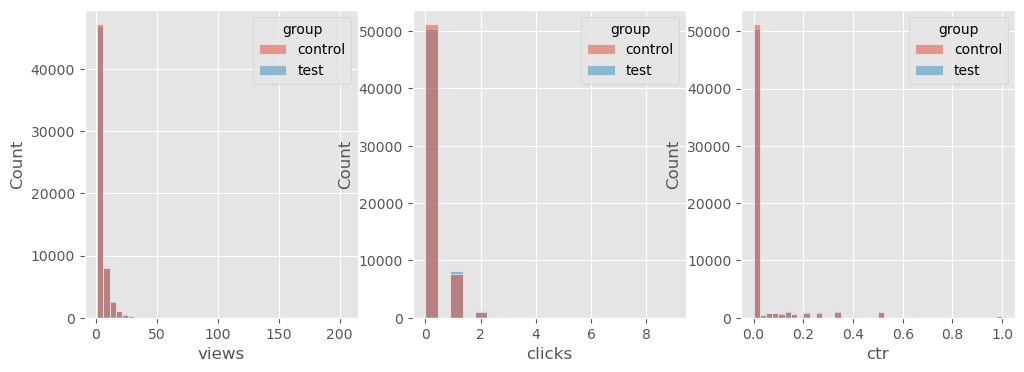

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.histplot(data=df, x='views', hue='group', bins=40, ax=axes[0])

sns.histplot(data=df, x='clicks', hue='group', bins=20, ax=axes[1])

sns.histplot(data=df, x='ctr', hue='group', bins=40, ax=axes[2])

#### Q-Q plots

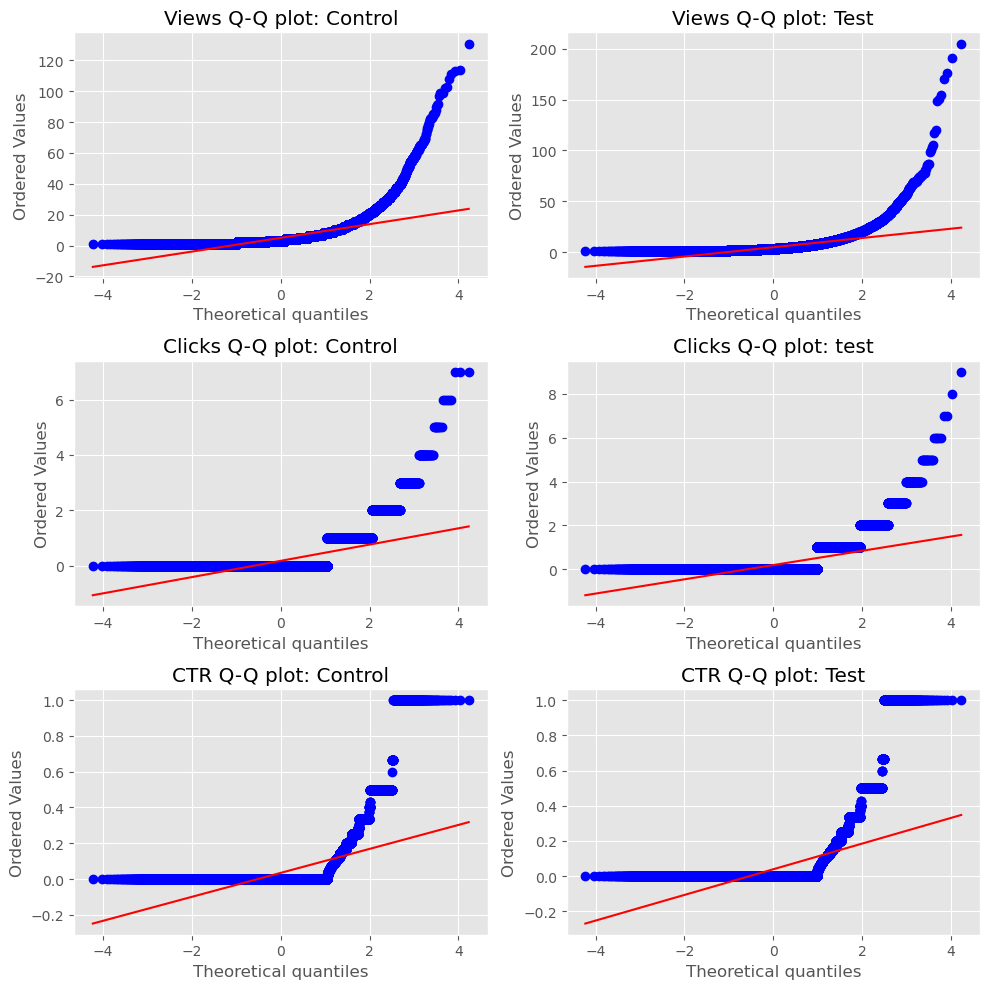

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(10,10))

stats.probplot(df[df['group'] == 'control']['views'], dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('Views Q-Q plot: Control')

stats.probplot(df[df['group'] == 'test']['views'], dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Views Q-Q plot: Test')

stats.probplot(df[df['group'] == 'control']['clicks'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Clicks Q-Q plot: Control')

stats.probplot(df[df['group'] == 'test']['clicks'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Clicks Q-Q plot: test')

stats.probplot(df[df['group'] == 'control']['ctr'], dist="norm", plot=axes[2, 0])
axes[2, 0].set_title('CTR Q-Q plot: Control')

stats.probplot(df[df['group'] == 'test']['ctr'], dist="norm", plot=axes[2, 1])
axes[2, 1].set_title('CTR Q-Q plot: Test')

plt.tight_layout()

#### Зависимость кликов и просмотров

<Axes: xlabel='views', ylabel='clicks'>

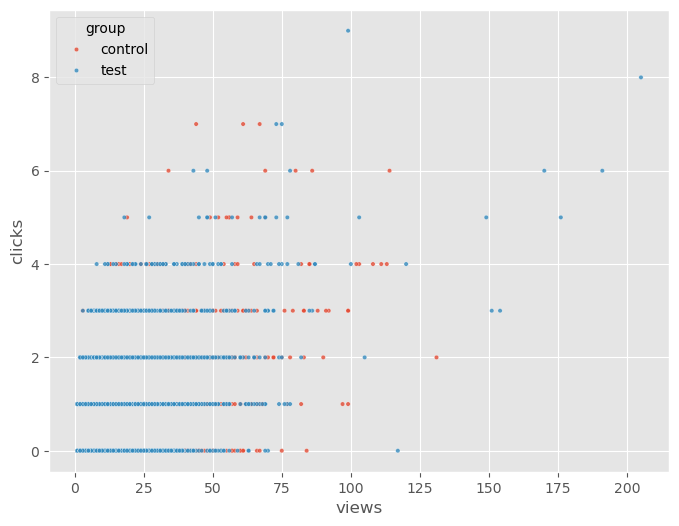

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='views', y='clicks', hue='group', alpha=0.8, s=10)

#### Box-plots для групп

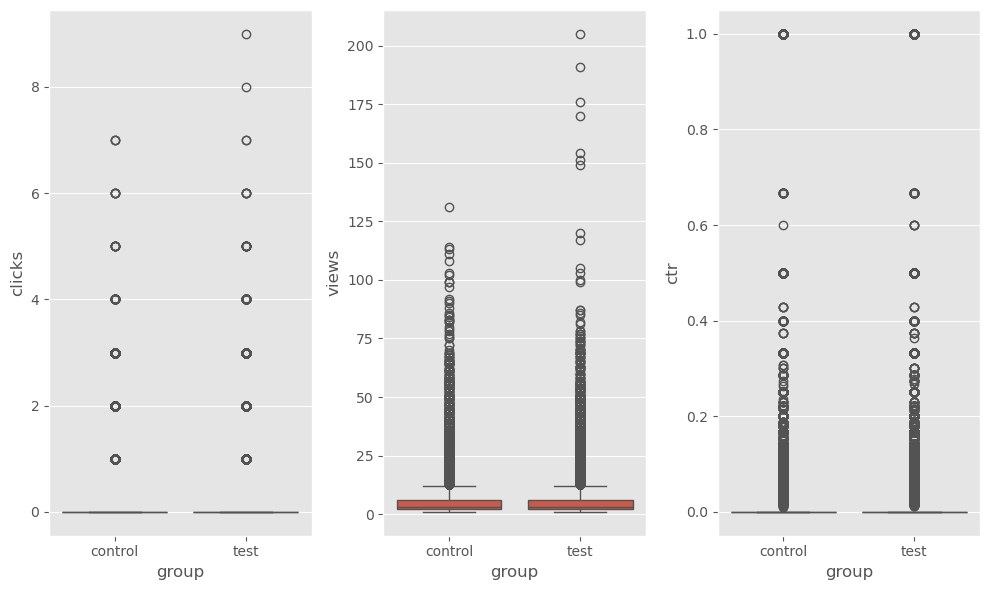

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(10, 6))

sns.boxplot(data=df, x='group', y='clicks', ax=axes[0])

sns.boxplot(data=df, x='group', y='views', ax=axes[1])

sns.boxplot(data=df, x='group', y='ctr', ax=axes[2])

plt.tight_layout()

Box‑plot подтверждает наличие выбросов, но они присутствуют в обеих группах.

#### Основные метрики

In [15]:
control_ctr = df[df['group'] == 'control']['ctr']
test_ctr = df[df['group'] == 'test']['ctr']

print(f'Среднее CTR Control: {control_ctr.mean()}')
print(f'Среднее CTR Test: {test_ctr.mean()}')
print(f"Разница: {test_ctr.mean() - control_ctr.mean():.4f} ({((test_ctr.mean() - control_ctr.mean())/control_ctr.mean()*100):+.2f}%)")

Среднее CTR Control: 0.034654433092805956
Среднее CTR Test: 0.038647582531410846
Разница: 0.0040 (+11.52%)


Общий CTR вырос на 0.38 % (+11.5% относительного прироста). 
Это предварительный сигнал в пользу тестовой группы.

In [18]:
control_ctr.describe()

count    60000.000000
mean         0.034654
std          0.114595
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: ctr, dtype: float64

In [17]:
test_ctr.describe()

count    60000.000000
mean         0.038648
std          0.120911
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: ctr, dtype: float64

## 3. Статистический анализ

- **Общий CTR** – доля успехов, подходит **Z‑тест для пропорций**
- **Пользовательский CTR** – распределение не нормальное, поэтому используем непараметрический **U‑тест Манна‑Уитни** (хотя для больших выборок t‑тест тоже даст адекватный результат, но U‑тест более устойчив к выбросам)

In [20]:
t_stat, p_value = stats.ttest_ind(control_ctr, test_ctr, equal_var=False)

print(f"T-статистика: {t_stat}")
print(f"P-value: {p_value}")

T-статистика: -5.871485328700077
P-value: 4.3304308150862265e-09


In [21]:
u_stat, u_p_value = stats.mannwhitneyu(control_ctr, test_ctr, alternative='two-sided')
print(f"U-статистика: {u_stat:.4f}")
print(f"P-value: {u_p_value}")

U-статистика: 1773003355.0000
P-value: 8.258019361570171e-13


In [22]:
clicks_test = df[df['group'] == 'test']['clicks'].sum()
views_test  = df[df['group'] == 'test']['views'].sum()
clicks_control = df[df['group'] == 'control']['clicks'].sum()
views_control  = df[df['group'] == 'control']['views'].sum()

p_test = clicks_test / views_test
p_control = clicks_control / views_control
print(f'CTR test: {p_test:.4f}')
print(f'CTR control: {p_control:.4f}')

CTR test: 0.0385
CTR control: 0.0347


In [23]:
z_stat, p_value = proportions_ztest(
    count=[clicks_test, clicks_control],
    nobs=[views_test, views_control],
    alternative='two-sided'   # можно 'larger' если априори ждём роста в тесте
)

print(f'Z-статистика: {z_stat:.3f}')
print(f'P-value: {p_value}')

Z-статистика: 7.894
P-value: 2.9379817526313143e-15


In [24]:
results = pd.DataFrame({
    'Метрика': ['Общий CTR', 'Средний CTR'],
    'Тест': ['Z‑тест пропорций', 'U‑тест Манна‑Уитни'],
    'Статистика': [f'Z={z_stat:.2f}', f'U={u_stat:.0f}'],
    'p‑value': [f'{p_value:.2e}', f'{u_p_value:.2e}'],
    'Значим (α=0.05)': ['Да' if p_value < 0.05 else 'Нет', 
                        'Да' if u_p_value < 0.05 else 'Нет']
})
results

,Метрика,Тест,Статистика,p‑value,Значим (α=0.05)
0,Общий CTR,Z‑тест пропорций,Z=7.89,2.94e-15,Да
1,Средний CTR,U‑тест Манна‑Уитни,U=1773003355,8.26e-13,Да


Оба теста показывают статистически значимое различие.

#### Доверительные интервалы для разницы в CTR

In [25]:
ci_control = proportion_confint(clicks_control, views_control, alpha=0.05, method='normal')
ci_test = proportion_confint(clicks_test, views_test, alpha=0.05, method='normal')

print(f'95% ДИ для control: {ci_control[0]:.4f} - {ci_control[1]:.4f}')
print(f'95% ДИ для test:    {ci_test[0]:.4f} - {ci_test[1]:.4f}')

diff = p_test - p_control
se_diff = np.sqrt((p_test*(1-p_test)/views_test) + (p_control*(1-p_control)/views_control))
ci_diff = (diff - 1.96*se_diff, diff + 1.96*se_diff)
print(f'Разница CTR: {diff:.4f}') 
print(f'95% ДИ для разницы: {ci_diff[0]:.4f} - {ci_diff[1]:.4f}')

95% ДИ для control: 0.0340 - 0.0353
95% ДИ для test:    0.0378 - 0.0392
Разница CTR: 0.0038
95% ДИ для разницы: 0.0029 - 0.0048


#### Доля привлеченных пользователей (clicks > 0)

In [26]:
control_engagement = df[(df['group'] == 'control') & (df['clicks'] > 0)]['user_id'].nunique()
test_engagement = df[(df['group'] == 'test') & (df['clicks'] > 0)]['user_id'].nunique()

control_engagement_rate = control_engagement / len(df[df['group'] == 'control'])
test_engagement_rate = test_engagement / len(df[df['group'] == 'test'])

print(f'Control - Всего привлеченных пользователей: {control_engagement} Процент: {control_engagement_rate*100:.2f}%')
print(f'Test - Всего привлеченных пользователей: {test_engagement} Процент: {test_engagement_rate*100:.2f}%')

Control - Всего привлеченных пользователей: 8820 Процент: 14.70%
Test - Всего привлеченных пользователей: 9703 Процент: 16.17%


## 4. Практическая значимость

In [27]:
h = 2 * np.arcsin(np.sqrt(p_test)) - 2 * np.arcsin(np.sqrt(p_control))
print(f"Cohen's h: {h:.4f}")

Cohen's h: 0.0204


Размер эффекта очень малый (h < 0.2) 

Несмотря на статистическую значимость, абсолютное увеличение CTR всего на 0.38 % 

# Выводы A/B‑теста

**Статистическая значимость:**

Новая версия страницы (test) показала статистически значимое увеличение общего CTR по сравнению с контрольной версией (control):
- Z‑тест для пропорций: p‑value < 0.0001
- U‑тест Манна‑Уитни для пользовательского CTR: p‑value < 0.0001

Оба теста показывают статистически значимое различие

**Размер эффекта и доверительный интервал:**

- Общий CTR вырос с 3.47% до 3.85%, абсолютный прирост составил 0.38% процентных пункта (относительный прирост ~ 11.5%)
- 95% доверительный интервал для разницы CTR: [0.29 %, 0.48 %] – не включает ноль, что согласуется с результатами тестов
- Однако размер эффекта по Cohen’s h = 0.02, что классифицируется как очень малый эффект

**Интерпретация и бизнес‑рекомендация:**

Хотя тестовая версия статистически значимо повышает CTR, абсолютный прирост невелик. Прежде чем принимать решение, необходимо:
- оценить влияние нового дизайна на другие конечные бизнес‑метрики (конверсию в покупку, доход)
- учесть затраты на разработку и поддержку изменений